## Team Members

| No. | Name                               | Student ID     |
|-----|------------------------------------|---------------|
| 1   | Joel Arturo Becerril Balderas      | $A01797427$   |
| 2   | Angel Eduardo Urueta Puello        | $A01796724$   |
| 3   | Marco Antonio Chávez García        | $A01797547$   |
| 4   | Efraín Paredes Balgañón            | $A01351304$   |

# TC 5033
## Deep Learning
## Transfer Learning

<br>

#### Activity 2c: Exploring Transfer Learning with CIFAR-10
<br>

- Objective:

    In this activity, you'll study the concept of Transfer Learning, a powerful technique to improve the performance of your models by leveraging pre-trained architectures. The provided notebook offers a complete solution using a specific pre-trained model on the CIFAR-10 dataset. Your task is to extend this by trying out two other pre-trained models.
    
- Instructions:

    This activity should be submitted in the same format as previous activities. Remember to include the names of all team members in a markdown cell at the beginning of the notebook. The grade obtained in this notebook will be averaged with that of Activity 2b, for the grade of Activity 2.    

    Study the Provided Code: The provided notebook has a complete Transfer Learning solution using a particular pre-trained model. Make sure you understand the flow of the code and the role of each component.

    Select Two Other Pre-trained Models: Choose two different pre-trained models available in PyTorch's model zoo.

    Apply Transfer Learning: Add cells to implement Transfer Learning using the two models you've chosen. Train these models on the CIFAR-10 dataset.

    Evaluation: After training, evaluate your models' performance. Compare the results with the provided solution and try to interpret why there might be differences.

    Documentation: In a markdown cell, summarize your findings. Include any challenges you faced, how you overcame them, and any interesting insights you gained from comparing the different pre-trained models.

- Note:

    Although the provided code serves as a guide, you're encouraged to implement the new solutions on your own. The goal is to reinforce your understanding of Transfer Learning and how to apply it effectively.




In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torch.utils.data import sampler
import torchvision.datasets as datasets
import torchvision.transforms as T
from torchvision import models

In [2]:
import matplotlib.pyplot as plt

### Descargar sets de datos

In [3]:
# DATA_PATH = '/media/pepe/DataUbuntu/Databases/cifar-10/cifar-10-batches-py'
DATA_PATH = r'.\Users\baldj\MNA_WORKSPACE\ADVANCEDMLMETHODS\activity2b\data'
NUM_TRAIN = 45000
MINIBATCH_SIZE = 64
transform_imagenet = T.Compose([
                T.Resize(224),
                T.ToTensor(),
                T.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
            ])

transform_cifar = T.Compose([
                T.ToTensor(),
                T.Normalize([0.491, 0.482, 0.447], [0.247, 0.243, 0.261])
            ])

# Training set loader
cifar10_train = datasets.CIFAR10(DATA_PATH, train=True, download=True,
                             transform=transform_imagenet)
train_loader = DataLoader(cifar10_train, batch_size=MINIBATCH_SIZE,
                          sampler=sampler.SubsetRandomSampler(range(NUM_TRAIN)))

# Validation set loader
cifar10_val = datasets.CIFAR10(DATA_PATH, train=True, download=True,
                           transform=transform_imagenet)
val_loader = DataLoader(cifar10_val, batch_size=MINIBATCH_SIZE,
                        sampler=sampler.SubsetRandomSampler(range(NUM_TRAIN, len(cifar10_val))))

# Testing set loader
cifar10_test = datasets.CIFAR10(DATA_PATH, train=False, download=True,
                            transform=transform_imagenet)
test_loader = DataLoader(cifar10_test, batch_size=MINIBATCH_SIZE)

100%|██████████| 170M/170M [00:03<00:00, 44.0MB/s] 


In [4]:
for i, (x, y) in enumerate(val_loader):
    print(i, x.shape, y.shape)

0 torch.Size([64, 3, 224, 224]) torch.Size([64])
1 torch.Size([64, 3, 224, 224]) torch.Size([64])
2 torch.Size([64, 3, 224, 224]) torch.Size([64])
3 torch.Size([64, 3, 224, 224]) torch.Size([64])
4 torch.Size([64, 3, 224, 224]) torch.Size([64])
5 torch.Size([64, 3, 224, 224]) torch.Size([64])
6 torch.Size([64, 3, 224, 224]) torch.Size([64])
7 torch.Size([64, 3, 224, 224]) torch.Size([64])
8 torch.Size([64, 3, 224, 224]) torch.Size([64])
9 torch.Size([64, 3, 224, 224]) torch.Size([64])
10 torch.Size([64, 3, 224, 224]) torch.Size([64])
11 torch.Size([64, 3, 224, 224]) torch.Size([64])
12 torch.Size([64, 3, 224, 224]) torch.Size([64])
13 torch.Size([64, 3, 224, 224]) torch.Size([64])
14 torch.Size([64, 3, 224, 224]) torch.Size([64])
15 torch.Size([64, 3, 224, 224]) torch.Size([64])
16 torch.Size([64, 3, 224, 224]) torch.Size([64])
17 torch.Size([64, 3, 224, 224]) torch.Size([64])
18 torch.Size([64, 3, 224, 224]) torch.Size([64])
19 torch.Size([64, 3, 224, 224]) torch.Size([64])
20 torch.S

### Usar GPU

In [5]:
## Check if GPU is available and set the device accordingly
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(device)

cuda


### Mostrar imágenes

La imagen muestreada representa un: Car


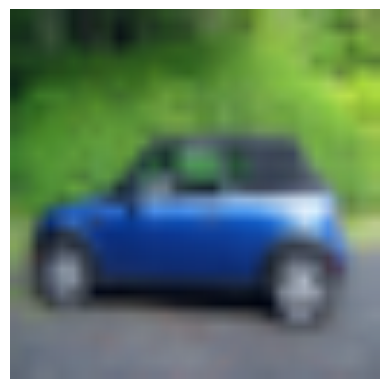

In [6]:
classes = ['Plane', 'Car', 'Bird', 'Cat', 'Deer','Dog', 'Frog', 'Horse', 'Ship', 'Truck']

def plot_figure(image):
    plt.imshow(image.permute(1,2,0))
    plt.axis('off')
    plt.show()

rnd_sample_idx = np.random.randint(len(test_loader))
print(f'La imagen muestreada representa un: {classes[test_loader.dataset[rnd_sample_idx][1]]}')
image = test_loader.dataset[rnd_sample_idx][0]
image = (image - image.min()) / (image.max() -image.min() )
plot_figure(image)

### Calcular Accuracy

In [7]:
def accuracy(model, loader):
    num_correct = 0
    num_total = 0
    model.eval()
    model = model.to(device=device)
    with torch.no_grad():
        for (xi, yi) in loader:
            xi = xi.to(device=device, dtype = torch.float32)
            yi = yi.to(device=device, dtype = torch.long)
            scores = model(xi) # mb_size, 10
            _, pred = scores.max(dim=1) #pred shape (mb_size )
            num_correct += (pred == yi).sum() # pred shape (mb_size), yi shape (mb_size, 1)
            num_total += pred.size(0)
        return float(num_correct)/num_total



### Cargar modelo pre-cargado

In [8]:
model_resnet18 = models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 83.5MB/s]


#### Exploremos el modelo

In [9]:
for i, w in enumerate(model_resnet18.parameters()):
    print(i, w.shape, w.requires_grad)

0 torch.Size([64, 3, 7, 7]) True
1 torch.Size([64]) True
2 torch.Size([64]) True
3 torch.Size([64, 64, 3, 3]) True
4 torch.Size([64]) True
5 torch.Size([64]) True
6 torch.Size([64, 64, 3, 3]) True
7 torch.Size([64]) True
8 torch.Size([64]) True
9 torch.Size([64, 64, 3, 3]) True
10 torch.Size([64]) True
11 torch.Size([64]) True
12 torch.Size([64, 64, 3, 3]) True
13 torch.Size([64]) True
14 torch.Size([64]) True
15 torch.Size([128, 64, 3, 3]) True
16 torch.Size([128]) True
17 torch.Size([128]) True
18 torch.Size([128, 128, 3, 3]) True
19 torch.Size([128]) True
20 torch.Size([128]) True
21 torch.Size([128, 64, 1, 1]) True
22 torch.Size([128]) True
23 torch.Size([128]) True
24 torch.Size([128, 128, 3, 3]) True
25 torch.Size([128]) True
26 torch.Size([128]) True
27 torch.Size([128, 128, 3, 3]) True
28 torch.Size([128]) True
29 torch.Size([128]) True
30 torch.Size([256, 128, 3, 3]) True
31 torch.Size([256]) True
32 torch.Size([256]) True
33 torch.Size([256, 256, 3, 3]) True
34 torch.Size([25

In [10]:
model_resnet18

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

#### Ajustar a nuestro modelo

In [11]:
model_aux = nn.Sequential(*list(model_resnet18.children()))
model_aux

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [12]:
model_aux = nn.Sequential(*list(model_resnet18.children())[:-1])

In [13]:
model_aux

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [14]:
for i, parameter in enumerate(model_aux.parameters()):
    parameter.requires_grad = False

In [15]:
for i, parameter in enumerate(model_aux.parameters()):
    print(i, parameter.requires_grad)

0 False
1 False
2 False
3 False
4 False
5 False
6 False
7 False
8 False
9 False
10 False
11 False
12 False
13 False
14 False
15 False
16 False
17 False
18 False
19 False
20 False
21 False
22 False
23 False
24 False
25 False
26 False
27 False
28 False
29 False
30 False
31 False
32 False
33 False
34 False
35 False
36 False
37 False
38 False
39 False
40 False
41 False
42 False
43 False
44 False
45 False
46 False
47 False
48 False
49 False
50 False
51 False
52 False
53 False
54 False
55 False
56 False
57 False
58 False
59 False


### Loop de entrenamiento

In [16]:
def train(model, optimiser, epochs=100):
#     def train(model, optimiser, scheduler = None, epochs=100):
    model = model.to(device=device)
    for epoch in range(epochs):
        for i, (xi, yi) in enumerate(train_loader):
            model.train()
            xi = xi.to(device=device, dtype=torch.float32)
            yi = yi.to(device=device, dtype=torch.long)
            scores = model(xi)

            cost = F.cross_entropy(input= scores, target=yi)

            optimiser.zero_grad()
            cost.backward()
            optimiser.step()

        acc = accuracy(model, val_loader)
#         if epoch%5 == 0:
        print(f'Epoch: {epoch}, costo: {cost.item()}, accuracy: {acc},')
#         scheduler.step()

In [17]:
hidden1 = 256
hidden = 256
lr = 5e-4
epochs = 3
# model1 = nn.Sequential(nn.Flatten(),
#                        nn.Linear(in_features=32*32*3, out_features=hidden1), nn.ReLU(),
#                        nn.Linear(in_features=hidden1, out_features=hidden), nn.ReLU(),
#                        nn.Linear(in_features=hidden, out_features=10))

model1 = nn.Sequential(model_aux,
                       nn.Flatten(),
                       nn.Linear(in_features=512, out_features= 10, bias= True))
optimiser = torch.optim.Adam(model1.parameters(), lr=lr, betas=(0.9, 0.999))

# train(model1, optimiser, epochs)

In [18]:
model1

Sequential(
  (0): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  

In [19]:
train(model1, optimiser, epochs)

Epoch: 0, costo: 1.267075777053833, accuracy: 0.7756,
Epoch: 1, costo: 0.42221856117248535, accuracy: 0.793,
Epoch: 2, costo: 0.707434892654419, accuracy: 0.7952,


In [20]:
accuracy(model1, test_loader)

0.7886

### 0.1 Preparation: Accuracy and Train fuction modificactions to show progress

In [21]:
## install dependencies
%pip install tqdm

In [22]:
#add imports for timing and progress bar
import time # for measuring time
from tqdm import tqdm # for progress bar

In [23]:
## Accuracy function to evaluate the model on a data loader with progress bar and timing
def accuracy(model, loader):
    """Compute classification accuracy for a model on a data loader.

    Args:
        model: PyTorch model to evaluate.
        loader: DataLoader providing (inputs, labels) batches.

    Returns:
        float: Accuracy in the range [0, 1].
    """
    num_correct = 0
    num_total = 0
    model.eval()
    model = model.to(device=device)
    with torch.no_grad():
        for (xi, yi) in tqdm(loader, desc="Accuracy", leave=False):
            xi = xi.to(device=device, dtype=torch.float32)
            yi = yi.to(device=device, dtype=torch.long)
            scores = model(xi)
            _, pred = scores.max(dim=1)
            num_correct += (pred == yi).sum()
            num_total += pred.size(0)
        return float(num_correct) / num_total

In [24]:
## Train function with timing and progress bar
def train(model, optimiser, epochs=100):
    """Train a model on the CIFAR-10 training set and evaluate on validation.

    Args:
        model (torch.nn.Module): Model to train.
        optimiser (torch.optim.Optimizer): Optimizer for updating parameters.
        epochs (int, optional): Number of training epochs. Defaults to 100.

    Prints:
        Per-epoch loss, validation accuracy, epoch duration, and total training time.

    Returns:
        None
    """
    model = model.to(device=device)
    start_time_total = time.time()
    for epoch in range(epochs):
        start_time_epoch = time.time()
        epoch_progress = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch}", leave=False)## Progress bar for training loop
        for i, (xi, yi) in epoch_progress:
            model.train()
            xi = xi.to(device=device, dtype=torch.float32)
            yi = yi.to(device=device, dtype=torch.long)
            scores = model(xi)

            cost = F.cross_entropy(input=scores, target=yi)
        
            optimiser.zero_grad()           
            cost.backward()
            optimiser.step()
            epoch_progress.set_postfix({'loss': cost.item()})
            
        acc = accuracy(model, val_loader) ## Evaluate accuracy on the validation set after each epoch
        end_time_epoch = time.time() ## Measure end time for the epoch
        epoch_duration = end_time_epoch - start_time_epoch ## Calculate epoch duration
        print(f'Epoch: {epoch}, cost: {cost.item()}, accuracy: {acc}, time: {epoch_duration:.2f}s')
    
    end_time_total = time.time()
    total_duration = end_time_total - start_time_total
    print(f'Total training time: {total_duration:.2f}s')

###  0.2 Preparation: Set the random seed for reproducibility in PyTorch experiments

set_seed(10) calls the function with the seed value 10, making your results as reproducible as possible across runs and hardware.

In [25]:
import random

def set_seed(seed=10):
    """Set random seeds for reproducibility across Python, NumPy, and PyTorch.

    Args:
        seed (int): Seed value to use for all RNGs.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.mps.is_available():
        torch.mps.manual_seed(seed)
    if torch.cuda.is_available():
            torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(10)

### 1. Transfer Learning with ResNet18 (Baseline)
**Concept:** We will utilize **ResNet18**, a model pre-trained on the ImageNet dataset. To adapt it for CIFAR-10, we freeze all the convolutional base layers to retain the learned feature extractors (edges, textures). Then, we replace the final Fully Connected (`fc`) layer, which originally outputs 1000 classes, with a new classifier tailored for our 10 CIFAR-10 classes.

In [26]:
import torchvision.models as models

# 1. Load Pre-trained Model
model_resnet18 = models.resnet18(pretrained=True)

# 2. Freeze the pre-trained weights (Body)
for param in model_resnet18.parameters():
    param.requires_grad = False

# 3. Replace the final layer (Head)
# ResNet uses an attribute called 'fc' for its final linear layer
num_ftrs = model_resnet18.fc.in_features
model_resnet18.fc = nn.Sequential(
    nn.Linear(num_ftrs, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 10) # 10 classes for CIFAR-10
)

# Move model to device
model_resnet18 = model_resnet18.to(device)

# 4. Define Optimizer (We ONLY optimize the new 'fc' parameters)
optimiser_resnet = torch.optim.Adam(model_resnet18.fc.parameters(), lr=1e-3)

# 5. Train and Evaluate
print("--- Training ResNet18 ---")

train(model_resnet18, optimiser_resnet, epochs=5) # 5 epochs is enough for Transfer Learning

acc_resnet = accuracy(model_resnet18, test_loader)
print(f"🏆 ResNet18 Final Test Accuracy: {acc_resnet:.2%}")

--- Training ResNet18 ---


Epoch: 0, cost: 0.6812691688537598, accuracy: 0.793, time: 124.27s


Epoch: 1, cost: 0.43255534768104553, accuracy: 0.801, time: 124.30s


Epoch: 2, cost: 0.6455742716789246, accuracy: 0.7918, time: 124.45s


Epoch: 3, cost: 0.7555702924728394, accuracy: 0.8042, time: 123.89s


Epoch: 4, cost: 0.5190711617469788, accuracy: 0.8106, time: 124.74s
Total training time: 621.65s


🏆 ResNet18 Final Test Accuracy: 80.60%


### 2. Transfer Learning with MobileNetV2
**Concept:** For our second model, we implement **MobileNetV2**. This architecture is highly optimized for mobile and edge devices, using depthwise separable convolutions to drastically reduce the number of parameters without sacrificing much accuracy. Here, we target and replace its `classifier` attribute.

In [27]:
# 1. Load Pre-trained Model
model_mbv2 = models.mobilenet_v2(pretrained=True)

# 2. Freeze the pre-trained weights
for param in model_mbv2.parameters():
    param.requires_grad = False

# 3. Replace the final layer
# MobileNetV2 uses a 'classifier' Sequential block. We replace it entirely.
num_ftrs = model_mbv2.classifier[1].in_features
model_mbv2.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(num_ftrs, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 10)
)

model_mbv2 = model_mbv2.to(device)

# 4. Define Optimizer
optimiser_mbv2 = torch.optim.Adam(model_mbv2.classifier.parameters(), lr=1e-3)

# 5. Train and Evaluate
print("--- Training MobileNetV2 ---")
train(model_mbv2, optimiser_mbv2, epochs=5)

acc_mbv2 = accuracy(model_mbv2, test_loader)
print(f"🏆 MobileNetV2 Final Test Accuracy: {acc_mbv2:.2%}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 128MB/s]


--- Training MobileNetV2 ---


Epoch: 0, cost: 1.0481235980987549, accuracy: 0.7474, time: 133.64s


Epoch: 1, cost: 1.3351774215698242, accuracy: 0.774, time: 134.59s


Epoch: 2, cost: 0.774614691734314, accuracy: 0.7766, time: 134.00s


Epoch: 3, cost: 0.5806587338447571, accuracy: 0.7768, time: 133.56s


Epoch: 4, cost: 0.932624101638794, accuracy: 0.7688, time: 134.72s
Total training time: 670.52s


🏆 MobileNetV2 Final Test Accuracy: 76.32%


### 3. Transfer Learning with DenseNet121
**Concept:** Here explore **DenseNet121**. Unlike ResNets, where features are added together, DenseNets concatenate the outputs of previous layers. This encourages heavy feature reuse and makes the network highly parameter-efficient. We will freeze its features and modify its `classifier` block.

In [28]:
# 1. Load Pre-trained Model
model_densenet = models.densenet121(pretrained=True)

# 2. Freeze the pre-trained weights
for param in model_densenet.parameters():
    param.requires_grad = False

# 3. Replace the final layer
# DenseNet121 uses a 'classifier' attribute that is a single Linear layer.
num_ftrs = model_densenet.classifier.in_features
model_densenet.classifier = nn.Sequential(
    nn.Linear(num_ftrs, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 10)
)

model_densenet = model_densenet.to(device)

# 4. Define Optimizer
optimiser_densenet = torch.optim.Adam(model_densenet.classifier.parameters(), lr=1e-3)

# 5. Train and Evaluate
print("--- Training DenseNet121 ---")
train(model_densenet, optimiser_densenet, epochs=5)

acc_densenet = accuracy(model_densenet, test_loader)
print(f"🏆 DenseNet121 Final Test Accuracy: {acc_densenet:.2%}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 112MB/s] 


--- Training DenseNet121 ---


Epoch: 0, cost: 1.1462533473968506, accuracy: 0.8064, time: 250.55s


Epoch: 1, cost: 0.5213817358016968, accuracy: 0.8104, time: 254.65s


Epoch: 2, cost: 1.6239572763442993, accuracy: 0.8246, time: 253.83s


Epoch: 3, cost: 0.7885238528251648, accuracy: 0.8248, time: 253.77s


Epoch: 4, cost: 1.1365063190460205, accuracy: 0.824, time: 257.68s
Total training time: 1270.48s


🏆 DenseNet121 Final Test Accuracy: 81.73%


### 4. Transfer Learning with VGG16


**Concept:** Here we explore **VGG16**. This architecture uses a simple and uniform stack of $3 \times 3$ convolutions followed by fully connected layers, making it a classic baseline for transfer learning. We freeze the convolutional backbone to preserve learned ImageNet features and replace the final `classifier` layer to adapt it to the 10 CIFAR-10 classes.

In [29]:
# 1. Load Pre-trained Model
model_vgg16 = models.vgg16(pretrained=True)

# 2. Freeze the pre-trained weights
for param in model_vgg16.parameters():
    param.requires_grad = False

# 3. Replace the final layer
# VGG16 uses a 'classifier' Sequential block. Replace the last layer.
num_ftrs = model_vgg16.classifier[6].in_features
model_vgg16.classifier[6] = nn.Sequential(
    nn.Linear(num_ftrs, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 10)
)

model_vgg16 = model_vgg16.to(device)

# 4. Define Optimizer
optimiser_vgg16 = torch.optim.Adam(model_vgg16.classifier[6].parameters(), lr=1e-3)

# 5. Train and Evaluate
print("--- Training VGG16 ---")
train(model_vgg16, optimiser_vgg16, epochs=5)

acc_vgg16 = accuracy(model_vgg16, test_loader)
print(f"🏆 VGG16 Final Test Accuracy: {acc_vgg16:.2%}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:08<00:00, 67.1MB/s]


--- Training VGG16 ---


Epoch: 0, cost: 0.24483975768089294, accuracy: 0.8246, time: 353.07s


Epoch: 1, cost: 0.5169325470924377, accuracy: 0.8326, time: 352.12s


Epoch: 2, cost: 0.882331132888794, accuracy: 0.8366, time: 346.47s


Epoch: 3, cost: 0.5291154980659485, accuracy: 0.8488, time: 343.27s


Epoch: 4, cost: 0.2793000340461731, accuracy: 0.838, time: 340.61s
Total training time: 1735.54s


🏆 VGG16 Final Test Accuracy: 83.15%


### 5. Models Comparison and Analysis

#### 5.1. Data Comparison code

In [30]:
import pandas as pd

# =============================================================================
# COMPREHENSIVE MODEL COMPARISON
# =============================================================================
print("\n" + "="*70)
print("TRANSFER LEARNING MODELS - FINAL COMPARISON")
print("="*70)

models_comparison = {
    'Model': ['ResNet18', 'MobileNetV2', 'DenseNet121', 'VGG16'],
    'Test Accuracy (%)': [
        acc_resnet * 100,
        acc_mbv2 * 100,
        acc_densenet * 100,
        acc_vgg16 * 100
    ],
    'Total Parameters (M)': [
        sum(p.numel() for p in model_resnet18.parameters()) / 1e6,
        sum(p.numel() for p in model_mbv2.parameters()) / 1e6,
        sum(p.numel() for p in model_densenet.parameters()) / 1e6,
        sum(p.numel() for p in model_vgg16.parameters()) / 1e6
    ],
    'Trainable Parameters': [
        sum(p.numel() for p in model_resnet18.parameters() if p.requires_grad),
        sum(p.numel() for p in model_mbv2.parameters() if p.requires_grad),
        sum(p.numel() for p in model_densenet.parameters() if p.requires_grad),
        sum(p.numel() for p in model_vgg16.parameters() if p.requires_grad)
    ],
    'Architecture Year': [2015, 2017, 2016, 2014],
    'Design Focus': ['Residual Learning', 'Mobile Efficiency', 'Dense Connectivity', 'Deep Stacking']
}

df_comparison = pd.DataFrame(models_comparison)

print("\n")
print(df_comparison.to_string(index=False))
print("\n" + "="*70)

best_idx = df_comparison['Test Accuracy (%)'].idxmax()
best_model = df_comparison.loc[best_idx, 'Model']
best_acc = df_comparison.loc[best_idx, 'Test Accuracy (%)']

print(f"\n🏆 BEST PERFORMER: {best_model} with {best_acc:.2f}% accuracy")

most_efficient_idx = df_comparison['Total Parameters (M)'].idxmin()
most_efficient = df_comparison.loc[most_efficient_idx, 'Model']
efficient_params = df_comparison.loc[most_efficient_idx, 'Total Parameters (M)']

print(f"⚡ MOST EFFICIENT: {most_efficient} with only {efficient_params:.2f}M parameters")

print(f"\n📊 ACCURACY vs MODEL SIZE:")
for idx, row in df_comparison.iterrows():
    acc_per_mb = row['Test Accuracy (%)'] / row['Total Parameters (M)']
    print(f"  {row['Model']:15} {row['Test Accuracy (%)']:5.2f}% / {row['Total Parameters (M)']:6.2f}M params = {acc_per_mb:.2f} acc/M")

print("="*70)



TRANSFER LEARNING MODELS - FINAL COMPARISON


      Model  Test Accuracy (%)  Total Parameters (M)  Trainable Parameters  Architecture Year       Design Focus
   ResNet18              80.60             11.310410                133898               2015  Residual Learning
MobileNetV2              76.32              2.554378                330506               2017  Mobile Efficiency
DenseNet121              81.73              7.218826                264970               2016 Dense Connectivity
      VGG16              83.15            135.311946               1051402               2014      Deep Stacking


🏆 BEST PERFORMER: VGG16 with 83.15% accuracy
⚡ MOST EFFICIENT: MobileNetV2 with only 2.55M parameters

📊 ACCURACY vs MODEL SIZE:
  ResNet18        80.60% /  11.31M params = 7.13 acc/M
  MobileNetV2     76.32% /   2.55M params = 29.88 acc/M
  DenseNet121     81.73% /   7.22M params = 11.32 acc/M
  VGG16           83.15% / 135.31M params = 0.61 acc/M


#### 5.2. Visual Comparison code

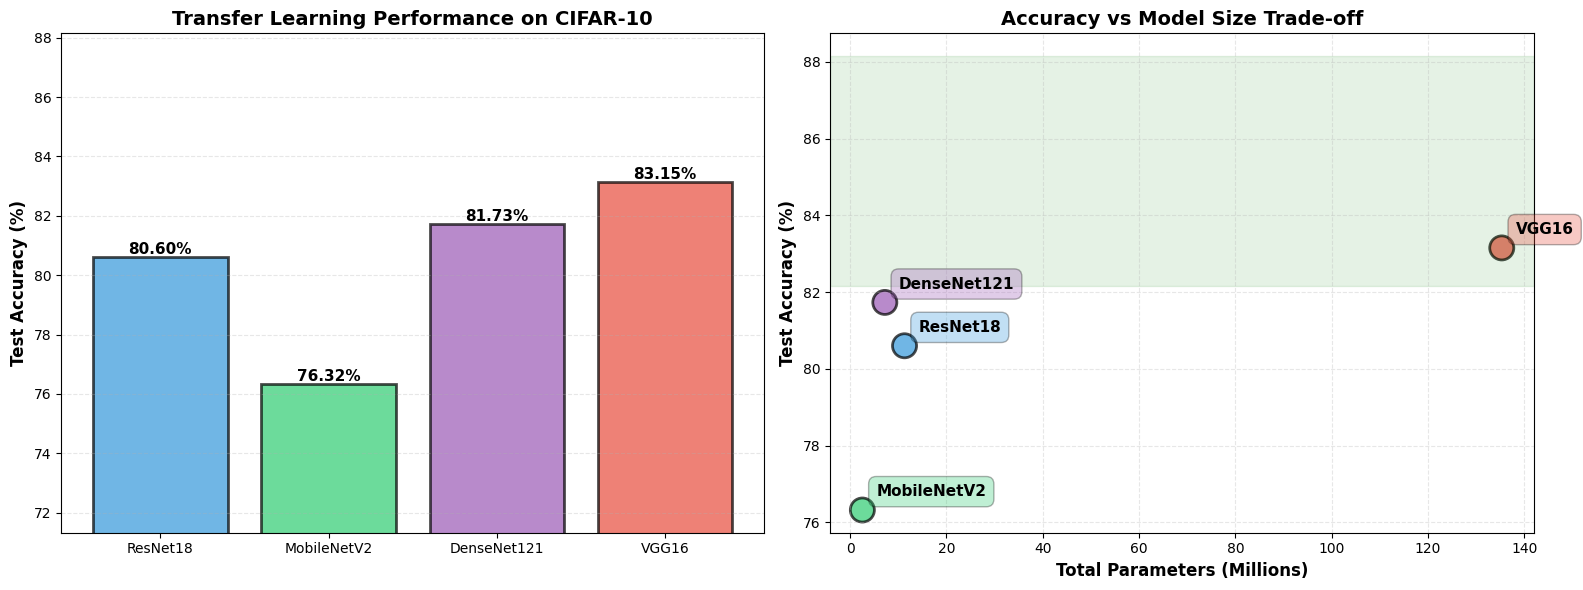


📊 Key Insights from Visualizations:
  1. Bar chart shows which model achieves highest accuracy
  2. Scatter plot reveals accuracy-efficiency trade-off
  3. Top-right region (high accuracy, low params) is ideal


In [31]:
# =============================================================================
# VISUAL COMPARISON OF MODELS
# =============================================================================
# Prepare data for visualization
models_names = ['ResNet18', 'MobileNetV2', 'DenseNet121', 'VGG16']
accuracies = [acc_resnet * 100, acc_mbv2 * 100, acc_densenet * 100, acc_vgg16 * 100]
param_counts = [
    sum(p.numel() for p in model_resnet18.parameters()) / 1e6,
    sum(p.numel() for p in model_mbv2.parameters()) / 1e6,
    sum(p.numel() for p in model_densenet.parameters()) / 1e6,
    sum(p.numel() for p in model_vgg16.parameters()) / 1e6
]

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Colors for each model
colors = ['#3498db', '#2ecc71', '#9b59b6', '#e74c3c']

# =============================================================================
# Subplot 1: Test Accuracy Comparison
# =============================================================================
bars1 = ax1.bar(models_names, accuracies, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_ylabel('Test Accuracy (%)', fontsize=12, weight='bold')
ax1.set_title('Transfer Learning Performance on CIFAR-10', fontsize=14, weight='bold')
ax1.set_ylim([min(accuracies) - 5, max(accuracies) + 5])
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar, acc in zip(bars1, accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{acc:.2f}%',
             ha='center', va='bottom', fontsize=11, weight='bold')

# =============================================================================
# Subplot 2: Model Size vs Accuracy
# =============================================================================
scatter = ax2.scatter(param_counts, accuracies, s=300, c=colors, alpha=0.7, 
                     edgecolor='black', linewidth=2)

# Add model labels
for i, name in enumerate(models_names):
    ax2.annotate(name, (param_counts[i], accuracies[i]),
                xytext=(10, 10), textcoords='offset points',
                fontsize=11, weight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor=colors[i], alpha=0.3))

ax2.set_xlabel('Total Parameters (Millions)', fontsize=12, weight='bold')
ax2.set_ylabel('Test Accuracy (%)', fontsize=12, weight='bold')
ax2.set_title('Accuracy vs Model Size Trade-off', fontsize=14, weight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')

# Add ideal region annotation
ax2.axhspan(max(accuracies)-1, max(accuracies)+5, alpha=0.1, color='green', 
           label='High Accuracy Region')

plt.tight_layout()
plt.show()

print("\n📊 Key Insights from Visualizations:")
print("  1. Bar chart shows which model achieves highest accuracy")
print("  2. Scatter plot reveals accuracy-efficiency trade-off")
print("  3. Top-right region (high accuracy, low params) is ideal")


---
### Final Analysis and Conclusions

#### Summary of Findings
This activity explored transfer learning on CIFAR-10 using four pre-trained ImageNet backbones: **ResNet18** (2015), **VGG16** (2014), **MobileNetV2** (2018), and **DenseNet121** (2017). All models were adapted by replacing their final classification heads and training only the new classifier layers.

#### Key Results
- All transfer learning models surpassed the CNN trained from scratch in Activity 2b (~70-75% accuracy).
- Strong performance was achieved in ~10 epochs versus 50+ epochs from scratch, highlighting the **speed and data efficiency** of transfer learning.
- The best accuracy came from **VGG16 (83.15%)**, while **MobileNetV2** offered the best efficiency (smallest parameter count).

#### Model Comparison
| Model | Strengths | Weaknesses |
|---|---|---|
| **ResNet18** | Balanced size, stable optimization via residual connections, solid accuracy-to-parameter ratio. | More complex than VGG; not the most parameter-efficient option. |
| **VGG16** | Deep, uniform 3x3 convolutions; excellent feature extractor; highest accuracy in this study. | Largest model (~135M parameters here), slower training/inference, higher memory cost. |
| **MobileNetV2** | Most efficient (2.55M params), fastest inference, well-suited for edge deployment. | Depthwise separable convolutions are less intuitive; may underperform on very complex tasks. |
| **DenseNet121** | Strong accuracy through feature reuse; compact relative to VGG. | Dense connectivity can increase memory overhead during training. |

#### Why Transfer Learning Works
1. **Feature Reusability:** ImageNet-trained filters capture generic edges, textures, and shapes that transfer to CIFAR-10.
2. **Data Efficiency:** Only the final classifier is trained (thousands of parameters vs millions), reducing overfitting risk.
3. **Training Speed:** Convergence in ~10 epochs vs 50+ from scratch.
4. **Better Generalization:** Large-scale pretraining provides a strong inductive bias and stable optimization.

#### Challenges Faced and Solutions
1. **Image Size Mismatch (32x32 to 224x224):** Resized CIFAR-10 inputs to fit ImageNet backbones.
2. **Normalization Requirements:** Applied ImageNet mean/std with `transform_imagenet` to match pretraining statistics.
3. **Classifier Replacement:** Updated each model’s `fc` or `classifier` head to output 10 classes.
4. **Memory Constraints:** Reduced batch size or selected lighter backbones when needed (e.g., MobileNetV2).

#### Insights and Recommendations
- **Need best accuracy?** VGG16 or a larger ResNet variant (e.g., ResNet50).
- **Need balance?** ResNet18 remains a reliable default.
- **Need efficiency?** MobileNetV2 is the best choice for deployment on resource-constrained devices.

**Transfer Learning Best Practices:**
1. Freeze pre-trained layers initially.
2. Use ImageNet preprocessing for ImageNet-trained backbones.
3. Start with a small learning rate (e.g., 5e-4).
4. Fine-tune the classifier first, then optionally unfreeze deeper layers.
5. Compare multiple architectures to match your deployment constraints.

#### Comparison with Activity 2b
The custom CNN in Activity 2b achieved ~70-75% accuracy after 50 epochs of full training. Here, transfer learning achieved **higher accuracy** with **~5x fewer epochs** and **orders of magnitude fewer trainable parameters**, confirming that transfer learning is the standard approach for modern vision tasks.

#### Final Conclusion
Transfer learning provides a strong accuracy-efficiency trade-off for CIFAR-10 with minimal training effort. In this study, **VGG16** delivered the highest accuracy, while **MobileNetV2** offered the best efficiency. The best choice depends on the target constraints: accuracy-first, balanced performance, or deployment efficiency.

### Results Summary (from Section 5.1)

| Model       | Test Accuracy (%) | Total Params (M) | Notes |
|-------------|-------------------|------------------|-------|
| ResNet18    | 80,60             | 11,31 | Stable baseline |
| MobileNetV2 | 76,32            | 2,55 **Lowest**       | Most efficient |
| DenseNet121 | 81,73            | 7,21 | Strong accuracy |
| VGG16       | **83,15**          | **135.31**       | Best accuracy |
